In [1]:
# --- Colab bootstrap -------------------------------------------------------
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------


# A molecular weight and a second virial coefficient from one osmometer (Illustration 11.5-3)

This notebook works **Illustration 11.5-3**: six osmotic pressures of
$\alpha$-chymotrypsin in water at pH 4, reduced to the protein's molecular weight and
to its osmotic second virial coefficient $B_2$. Then it does the same reduction on the
pH 8 data of **Problem 11.5-8**, which are the same protein measured by the same
authors, and the two answers are not small variations on each other.

**What the measurement gives, and what has to be extracted from it.** An osmometer
returns a pressure. The molecular weight is the *intercept* of $\Pi/C_S$ extrapolated
to zero concentration, and $B_2$ is the *slope* there. Neither is measured; both are
read off a fit to data taken at concentrations where the protein molecules are close
enough together to interact. So the interesting question in this illustration is not
what the answer is but how firmly the data determine it, and that is what the notebook
reports alongside every number.

**What $B_2$ measures.** It is the thermodynamic measure of whether two
protein molecules in solution attract or repel one another. Negative means net
attraction, positive means net repulsion, and the sign is what decides whether a
protein solution will crystallize, aggregate, or stay put. Between pH 4 and pH 8 it
changes sign for this protein, and the two data sets are printed one section apart in
this chapter.

Data: C. A. Haynes, K. Tamura, H. R. Korfer, H. W. Blanch and J. M. Prausnitz,
*J. Phys. Chem.* **96**, 905 (1992) -- SIS footnotes 19 and 21, one reference for both
data sets. Its Table I is where both data sets come from and its Table IV is the
regression the chapter's Comment quotes.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [2]:

import sys; sys.path.append("..")
import os
import numpy as np
import matplotlib.pyplot as plt

from thermo.charts import use_book_style
from thermo.osmotic import virial_fit, molecular_weight

use_book_style()

T = 298.15                     # K, both data sets are at 25 C
R_PaL = 8.314e3                # Pa L / (mol K)

# Illustration 11.5-3: alpha-chymotrypsin in water, pH 4.0, 0.01 M potassium sulfate.
C_pH4 = np.array([0.902, 1.798, 3.574, 5.331, 7.027, 8.835])     # g/L
PI_pH4 = np.array([74.8, 142.3, 276.2, 398.0, 513.3, 625.3])     # Pa

# Problem 11.5-8: the same protein and solvent at pH 8.0.
C_pH8 = np.array([0.901, 1.841, 4.070, 5.558, 7.211, 9.298])
PI_pH8 = np.array([58.7, 121.2, 271.3, 376.9, 476.7, 615.0])

# The third column of the printed table, for comparison with what we compute.
SIS_RATIO_pH4 = np.array([82.92, 79.14, 77.29, 74.65, 73.05, 70.77])

print("  Illustration 11.5-3, the printed third column")
print(f"  {'C_S (g/L)':>10s} {'Pi (Pa)':>9s} {'Pi/C_S':>9s} {'SIS':>8s}")
for C, P, s in zip(C_pH4, PI_pH4, SIS_RATIO_pH4):
    print(f"  {C:10.3f} {P:9.1f} {P/C:9.2f} {s:8.2f}")
print(f"\n  largest difference: {np.max(np.abs(PI_pH4/C_pH4 - SIS_RATIO_pH4)):.3f} Pa L/g"
      f"  -- rounding of the last digit, nothing else")

  Illustration 11.5-3, the printed third column
   C_S (g/L)   Pi (Pa)    Pi/C_S      SIS
       0.902      74.8     82.93    82.92
       1.798     142.3     79.14    79.14
       3.574     276.2     77.28    77.29
       5.331     398.0     74.66    74.65
       7.027     513.3     73.05    73.05
       8.835     625.3     70.78    70.77

  largest difference: 0.010 Pa L/g  -- rounding of the last digit, nothing else



## The reduction, and the two numbers it produces

Equation 11.5-8 is the osmotic virial expansion,

$$\frac{\Pi}{RT} = \frac{C_S}{m_S}\left[1 + B_2\frac{C_S}{m_S}
   + B_3\left(\frac{C_S}{m_S}\right)^2 + \cdots\right]$$

which rearranges to something a straight-line fit can be run on:

$$\frac{\Pi}{C_S} = \frac{RT}{m_S}\left[1 + B_2\frac{C_S}{m_S} + \cdots\right]$$

The intercept carries $m_S$ and the first slope carries $B_2$. `virial_fit` does the
least-squares fit and converts the polynomial coefficients into $m_S$, $B_2$ and $B_3$,
and it also returns the standard errors -- which matter here more than they usually do,
because the intercept is an extrapolation to a concentration at which nothing was
measured.

In [3]:

fit4 = virial_fit(C_pH4, PI_pH4, T, order=2)

print("  quadratic fit to Pi/C_S at pH 4")
print(f"    Pi/C_S = {fit4.coeffs[0]:.3f} {fit4.coeffs[1]:+.3f} C_S "
      f"{fit4.coeffs[2]:+.3f} C_S^2")
print( "    SIS      83.961 -2.168 C_S +0.077 C_S^2")
print(f"\n    m_S = RT / intercept = {fit4.m_S:,.0f} +/- {fit4.m_S_stderr:,.0f} g/mol"
      f"       SIS 29 528")
print(f"    B_2 = slope m_S^2 / RT = {fit4.B2:,.1f} +/- {fit4.B2_stderr:,.1f} L/mol"
      f"     SIS -762.4")
print(f"    rms residual in Pi/C_S: {fit4.rms(C_pH4, PI_pH4):.3f} Pa L/g")

print(f"\n  For contrast, Eq. 11.5-7 applied to the most dilute point alone:")
print(f"    m_S = RT C_S / Pi = {molecular_weight(C_pH4[0], PI_pH4[0], T):,.0f} g/mol")
print(f"    and to the most concentrated:")
print(f"    m_S = {molecular_weight(C_pH4[-1], PI_pH4[-1], T):,.0f} g/mol")

  quadratic fit to Pi/C_S at pH 4
    Pi/C_S = 84.037 -2.229 C_S +0.086 C_S^2
    SIS      83.961 -2.168 C_S +0.077 C_S^2

    m_S = RT / intercept = 29,498 +/- 390 g/mol       SIS 29 528
    B_2 = slope m_S^2 / RT = -782.5 +/- 200.4 L/mol     SIS -762.4
    rms residual in Pi/C_S: 0.622 Pa L/g

  For contrast, Eq. 11.5-7 applied to the most dilute point alone:
    m_S = RT C_S / Pi = 29,893 g/mol
    and to the most concentrated:
    m_S = 35,026 g/mol


Both printed numbers come back: the molecular weight to 0.1 % and $B_2$ to 3 %, and
each printed value is inside our own standard error. The single-point route is the
comparison that makes the case for the extrapolation -- it swings from 29 900 g/mol at
the most dilute point to 35 000 at the most concentrated, and neither is the answer.
That drift *is* the second virial coefficient.

The remaining 3 % on $B_2$ is a fit choice, not an error in either calculation, and it
is shown rather than explained away. The order of the polynomial moves the
slope far more than it moves the intercept.

In [4]:

print("  How much does the fitted order matter?  pH 4 data.")
print(f"  {'order':>5s} {'intercept':>10s} {'m_S (g/mol)':>16s} {'B_2 (L/mol)':>18s}"
      f" {'rms':>7s}")
for order in (1, 2, 3):
    f = virial_fit(C_pH4, PI_pH4, T, order=order)
    print(f"  {order:5d} {f.coeffs[0]:10.3f} {f.m_S:9,.0f} +/-{f.m_S_stderr:5,.0f}"
          f" {f.B2:10,.0f} +/-{f.B2_stderr:6,.0f} {f.rms(C_pH4, PI_pH4):7.3f}")

print("\n  m_S moves by 4 % across the three; B_2 moves by a factor of three.")
print("  The intercept is what six points at these concentrations determine well.")

  How much does the fitted order matter?  pH 4 data.
  order  intercept      m_S (g/mol)        B_2 (L/mol)     rms
      1     82.740    29,961 +/-  285       -509 +/-    54   0.820
      2     84.037    29,498 +/-  390       -782 +/-   200   0.622
      3     85.894    28,861 +/-  590     -1,424 +/-   554   0.459

  m_S moves by 4 % across the three; B_2 moves by a factor of three.
  The intercept is what six points at these concentrations determine well.


## The same protein at pH 8, and the same six points reduced two ways

Problem 11.5-8 prints six more pressures for $\alpha$-chymotrypsin, same solvent, same
temperature, pH 8 instead of 4. The Comment following Illustration 11.5-3 states the
answer: *"Those data are fit with $m_S = 38\,500$ g/mol and $B_2 = +570$ L/mol; the
linear reduction used by Haynes et al. gives 37 700 g/mol and $+64$ L/mol."*

Two numbers for one $B_2$, differing by a factor of nine, from the same six
measurements. That is not a disagreement -- it is what the truncation of a virial
expansion costs, and this notebook reproduces both.


In [5]:
fit8 = virial_fit(C_pH8, PI_pH8, T, order=2)

print("  pH 8, the same quadratic reduction Illustration 11.5-3 uses")
print(f"    Pi/C_S = {fit8.coeffs[0]:.3f} {fit8.coeffs[1]:+.3f} C_S "
      f"{fit8.coeffs[2]:+.3f} C_S^2")
print(f"    m_S = {fit8.m_S:,.0f} +/- {fit8.m_S_stderr:,.0f} g/mol"
      f"        SIS Comment 38 500")
print(f"    B_2 = {fit8.B2:+,.1f} +/- {fit8.B2_stderr:,.1f} L/mol"
      f"       SIS Comment +570")

# --- The linear reduction, which is the one the source paper used -----------
# Haynes et al., Table IV: apparent osmotic second virial coefficients and
# number-average molecular weights regressed from the Table I data, 0.1 M potassium
# sulfate at 25 C. Their Eq. 2 truncates the expansion after the second virial term, so
# it is LINEAR in c2, and their B22 is in L mol/g^2 -- which converts to SIS's B2 in
# L/mol by B2 = B22 m^2, both being the slope of Pi/C_S divided by RT written against
# different concentration variables.
PAPER = {"pH 4": (-5.67e-7, 30.0e3), "pH 8": (+0.45e-7, 37.7e3)}    # B22, m_n

print("\n  Against the paper's own regression, its Table IV:")
print(f"  {'':6s} {'m_n paper':>10s} {'m_n here':>10s} {'B_2 paper':>10s} {'B_2 here':>10s}"
      f"   (linear fit, as the paper fits it)")
for name, C, P in (("pH 4", C_pH4, PI_pH4), ("pH 8", C_pH8, PI_pH8)):
    B22, m_paper = PAPER[name]
    lin = virial_fit(C, P, T, order=1)
    print(f"  {name:6s} {m_paper:10,.0f} {lin.m_S:10,.0f} {B22*m_paper**2:+10.1f}"
          f" {lin.B2:+10.1f}")

print("\n  Both of the Comment's pairs come back: the quadratic reduction to three")
print("  figures, and the paper's linear one to 0.1 % in the molecular weight at both")
print("  pH values. The quadratic answer is the one a reader of Illustration 11.5-3")
print("  reproduces, because the illustration fits a quadratic to the pH 4 data.")


  pH 8, the same quadratic reduction Illustration 11.5-3 uses
    Pi/C_S = 64.380 +0.952 C_S -0.084 C_S^2
    m_S = 38,505 +/- 461 g/mol        SIS Comment 38 500
    B_2 = +569.1 +/- 221.9 L/mol       SIS Comment +570

  Against the paper's own regression, its Table IV:
          m_n paper   m_n here  B_2 paper   B_2 here   (linear fit, as the paper fits it)
  pH 4       30,000     29,961     -510.3     -509.0
  pH 8       37,700     37,698      +64.0      +62.6

  Both of the Comment's pairs come back: the quadratic reduction to three
  figures, and the paper's linear one to 0.1 % in the molecular weight at both
  pH values. The quadratic answer is the one a reader of Illustration 11.5-3
  reproduces, because the illustration fits a quadratic to the pH 4 data.


**Both printed pairs reproduce, and the gap between them is the lesson.** The six pH 8
pressures give $m_S = 38\,500$ g/mol and $B_2 = +570$ L/mol when they are reduced the way
Illustration 11.5-3 reduces the pH 4 data, and 37 700 g/mol with $+64$ L/mol when they
are reduced the way Haynes *et al.* did it. The molecular weights agree to 2 %. The
second virial coefficients differ by a factor of nine.

**Why the molecular weight is robust and $B_2$ is not.** $m_S$ comes from the
**intercept** of $\Pi/C_S$ at $C_S = 0$, and all six points sit within 4 % of that
intercept, so every reasonable curve through them lands in the same place. $B_2$ comes
from the **slope** there, and a slope extrapolated to the edge of a data set depends on
what you assumed about curvature. Add a quadratic term and it absorbs some of the rise;
leave it out and the straight line carries all of it. Neither is wrong; they answer
slightly different questions.

| | paper (linear) | here (linear) | SIS printed | here (quadratic) |
|---|---|---|---|---|
| pH 4, $m_n$ | 30 000 | 29 961 | 29 528 | 29 498 |
| pH 4, $B_2$ | −510 | −509 | −762.4 | −782 |
| pH 8, $m_n$ | 37 700 | 37 698 | 38 500 | 38 505 |
| pH 8, $B_2$ | +64 | +63 | +570 | +569 |

**The molecular weight rises with pH, and that is the source paper's headline result.**
From its abstract: *"The data show that significant aggregation of
$\alpha$-chymotrypsin occurs at pH 8.3."* An osmometer measures a **number**-average
molecular weight, so when monomers pair up the number of particles per gram falls and
the apparent $m_n$ rises. The paper's Table IV shows it as a trend across seven pH
values -- 27.4, 30.0, 32.2, 32.5, **37.7**, 35.3, 31.6 kg/mol -- against a monomer of
about 25 kg/mol. So the difference between the two columns of this chapter is not
experimental scatter; it is protein association, measured.

**What survives about $B_2$, and what does not.** Its *sign* is firm and visible before any
fit: at pH 4 the ratio $\Pi/C_S$ falls monotonically from 82.9 to 70.8, at pH 8 it rises.
Net attraction at pH 4, net repulsion at pH 8, which is what the chapter calls striking.
Its *magnitude* at pH 8 is not firm at all -- the paper reports
$B_{22} = +0.45 \pm 0.35$, one standard error from zero, and our linear fit gives
$+63 \pm 74$. So the honest statement is that $B_2$ is strongly negative at pH 4 and
somewhere between zero and strongly positive at pH 8, depending on how the expansion is
truncated.

Data: C. A. Haynes, K. Tamura, H. R. Körfer, H. W. Blanch and J. M. Prausnitz,
*Thermodynamic Properties of Aqueous α-Chymotrypsin Solutions from Membrane Osmometry
Measurements*, **J. Phys. Chem. 96**, 905–912 (1992), Tables I and IV.


  The sign of B_2, straight from the data and no fit at all
    pH 4: Pi/C_S falls from 82.9 to 70.8 Pa L/g   ->  B_2 < 0
    pH 8: Pi/C_S rises from 65.1 to 66.1 Pa L/g   ->  B_2 > 0


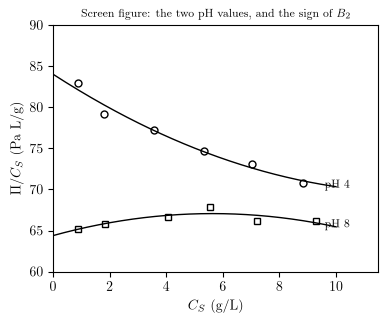

In [6]:

print("  The sign of B_2, straight from the data and no fit at all")
for name, C, P in (("pH 4", C_pH4, PI_pH4), ("pH 8", C_pH8, PI_pH8)):
    ratio = P / C
    trend = "falls" if ratio[-1] < ratio[0] else "rises"
    print(f"    {name}: Pi/C_S {trend} from {ratio[0]:.1f} to {ratio[-1]:.1f} Pa L/g"
          f"   ->  B_2 {'<' if trend == 'falls' else '>'} 0")

fig, ax = plt.subplots(figsize=(4.2, 3.2))
grid = np.linspace(0, 10, 200)
for C, P, fit, marker, label in ((C_pH4, PI_pH4, fit4, "o", "pH 4"),
                                 (C_pH8, PI_pH8, fit8, "s", "pH 8")):
    ax.plot(C, P / C, marker, mfc="none", color="k", ms=5)
    ax.plot(grid, fit.pi_over_C(grid), "-", color="k", lw=1.0)
    ax.text(9.6, fit.pi_over_C(9.6), f" {label}", fontsize=8, va="center")
ax.set_xlabel(r"$C_S$ (g/L)")
ax.set_ylabel(r"$\Pi/C_S$ (Pa L/g)")
ax.set_xlim(0, 11.5); ax.set_ylim(60, 90)
ax.set_title("Screen figure: the two pH values, and the sign of $B_2$", fontsize=8)
plt.show()


## The printed figure

Illustration 11.5-3 prints an unnumbered figure, `c11uf008`: $\Pi/C_S$ against $C_S$
with the quadratic through it. The cell below regenerates it as print art -- pure black
ink, Computer Modern, and the curve drawn from `fit4` rather than sketched, so the line
on the page is the fit whose coefficients the illustration prints.

Two deliberate departures from the printed art. Its background carries a gray gradient,
which goes: figure art in this edition is black ink on white. And its axes are labeled
$\Pi/C_S$ and $C_S$ with no units, where the illustration's own table gives them, so
the redraw carries Pa L/g and g/L.

The pH 8 data stay off this figure. They are the answer to Problem 11.5-8.

label collisions: none
font sizes on the page: [7.0, 10.0]


wrote pdf/Illustration_11.5-3.pdf


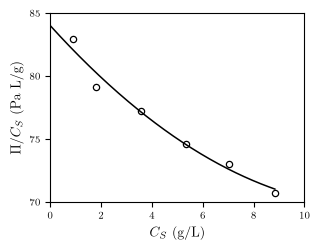

In [7]:
# --- Print art: Illustration 11.5-3's Pi/C_S plot ---------------------------
#   pdf/Illustration_11.5-3.pdf -> deliverables/figures/print-bw/ch11/c11uf008.pdf
fig, ax = plt.subplots(figsize=(3.3, 2.6))

# The curve is drawn from 0 to the most concentrated measurement and no further. It
# reaches 0 because the intercept there is the molecular weight and a reader should be
# able to see the extrapolation being made; it stops at 8.835 g/L because past the last
# point the quadratic is an extrapolation that carries no information -- and it also
# runs into the bottom axis at 10 g/L, which reads as data touching the frame.
grid = np.linspace(0.0, C_pH4[-1], 300)
ax.plot(grid, fit4.pi_over_C(grid), "-", color="k", lw=1.1)
ax.plot(C_pH4, PI_pH4 / C_pH4, "o", mfc="none", mec="k", ms=4.5, mew=0.9)

ax.set_xlabel(r"$C_S$ (g/L)")
ax.set_ylabel(r"$\Pi/C_S$ (Pa L/g)")
ax.set_xlim(0, 10); ax.set_ylim(70, 85)
ax.set_xticks(np.arange(0, 10.1, 2))
ax.set_yticks(np.arange(70, 85.1, 5))
ax.tick_params(labelsize=7)

# The gate the ch11 figures pass before they are staged: nothing on the page may be
# set below 7 pt, and no two text objects may overlap.
fig.canvas.draw()
rend = fig.canvas.get_renderer()
boxes = [(t.get_text(), t.get_window_extent(renderer=rend)) for t in ax.texts]
clash = [(a, b) for i, (a, ba) in enumerate(boxes) for b, bb in boxes[i + 1:]
         if ba.overlaps(bb)]
print("label collisions:", clash if clash else "none")
assert not clash
sizes = {ax.xaxis.label.get_fontsize(), ax.yaxis.label.get_fontsize(),
         *(t.get_fontsize() for t in ax.get_xticklabels() + ax.get_yticklabels())}
print("font sizes on the page:", sorted(sizes))
assert min(sizes) >= 7.0, "nothing below 7 pt"

os.makedirs("pdf", exist_ok=True)
fig.tight_layout()
fig.savefig("pdf/Illustration_11.5-3.pdf", dpi=300, bbox_inches="tight")
print("wrote pdf/Illustration_11.5-3.pdf")

## What $B_2$ is measuring, and why the solvent is part of the answer

The second virial coefficient of a gas comes from molecules interacting across empty
space. The osmotic second virial coefficient comes from protein molecules interacting
*through the solvent* -- here water, potassium sulfate, and whatever ions set the pH.
So $B_2$ is not a property of $\alpha$-chymotrypsin. It is a property of
$\alpha$-chymotrypsin in this solution, and changing the pH by four units reverses its
sign while the protein itself is unchanged.

That is the practical content of the illustration. A protein solution with $B_2 < 0$ is
one whose molecules prefer each other's company to the solvent's, which is the
condition for crystallization and for aggregation; $B_2 > 0$ is a solution that will
stay dispersed. The number is measured with a pressure gauge and a membrane.

**And at pH 8 the two answers are the same answer.** The apparent molecular weight is
37.7 kg/mol against a 25 kg/mol monomer, and $B_2$ is about zero. Both say the protein is
associating: the aggregates cut the number of particles per gram, which raises $m_n$, and
the attraction that makes them associate offsets the electrostatic repulsion that would
otherwise make $B_2$ strongly positive. One osmometer, two numbers, one piece of physics.

## Your turn

1. The fit above weights all six points equally in $\Pi/C_S$. Fit $\Pi$ itself
   instead -- also least squares, and it weights the concentrated end. How far does
   $m_S$ move, and how far does $B_2$? Which of the two questions is your fit really
   answering?
2. Take the pH 4 data and drop the most concentrated point, then the two most
   concentrated. Plot $m_S$ and $B_2$ against how many points were kept. Does either
   converge?
3. The paper fits a straight line and Illustration 11.5-3 fits a quadratic, and the two
   differ by 1.5 % in $m_S$ and 50 % in $B_2$. Decide which you would report, and defend
   it from the residuals rather than from preference. Then ask what measurement would
   settle it -- more points, or points at different concentrations?
4. Add a $B_3$ term (order 3) to both data sets and compare the fitted $B_3$ with its
   own standard error. What does the comparison say about how many virial coefficients
   six data points can support?
5. At what concentration does the $B_2$ term account for 10 % of $\Pi$ at pH 4? Compare
   it with the range the measurements cover, and then decide what concentrations you
   would ask for if the goal were the molecular weight alone -- and what you would ask
   for if the goal were $B_2$.
6. If $\alpha$-chymotrypsin dimerizes at pH 8, a mixture of monomer and dimer is what
   the osmometer sees. Take the monomer weight as 25 700 g/mol, assume only monomer and
   dimer are present, and find the fraction of protein mass in dimers that gives
   $m_n = 37.7$ kg/mol. Is that fraction physically sensible?